In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.00 — Shared-basis GLM-HMM: principled K selection

Triangulate the number of states for the **shared HC+PD basis** fit by
`scripts/shared_glm_hmm/fit_shared_basis.py`. Four independent criteria on one figure:

1. **Held-out CV bits/trial** (test, with train overlay) — predictive fit; look for the plateau.
2. **BIC** — penalised fit (lower = better).
3. **ICL** — BIC + posterior-assignment entropy; rewards *well-separated* states, the
   quantity matched to 'how many distinct strategies' (lower = better).
4. **Bootstrap state-stability** — reproducibility of the K-state solution across session
   resamples; the largest K that stays reproducible is supported.

Pick the K where these **converge**; that K is then passed to `finetune_shared_basis.py --best-k`.

In [3]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imports import *
from config import dir_config
from src.glm_hmm.cv_utils import bernoulli_null_loglik, pooled_bits_per_trial
from src.shared_glm_hmm.selection import icl_bic, bootstrap_state_stability

In [4]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"

CONFIG = "XY__tgt"  # run dir under shared_glm_hmm/; "XY__tgt_std" = standardized sensitivity run
cv_path = shared_dir / CONFIG / "all_subjects.pkl"

bundle = pickle.load(open(cv_path, "rb"))
feats = bundle["config"]["model_features"]
states = np.asarray(bundle["group_pooled_cv"]["state_range"])
print(f"config={CONFIG}  features={feats}")
print(f"state range={list(states)}  n_sessions={len(bundle['data'])}")

config=ashwood_color_non_standardized  features=['stimulus', 'color', 'bias', 'prev_choice_1', 'prev_target_1', 'prev_choice_target_1']
state range=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n_sessions=100


## 1. CV held-out bits/trial (test + train)

In [5]:
def pooled_bits(bundle):
    gpc = bundle["group_pooled_cv"]
    null_ll, n_valid = bernoulli_null_loglik(bundle["data"])
    mean_bits, sem_bits = pooled_bits_per_trial(gpc["test_ll"], gpc["n_test_trials"], null_ll, n_valid)
    return np.asarray(gpc["state_range"]), mean_bits, sem_bits


def pooled_train_bits(bundle):
    gpc = bundle["group_pooled_cv"]
    null_ll, n_valid = bernoulli_null_loglik(bundle["data"])
    train_ll, n_train = gpc["train_ll"], gpc["n_train_trials"]
    bits_fold = (train_ll - null_ll * (n_train / n_valid)) / (n_train * np.log(2))
    return np.asarray(gpc["state_range"]), bits_fold.mean(1), bits_fold.std(1) / np.sqrt(bits_fold.shape[1])


def parsimonious_k(states, mean_bits, sem_bits):
    best_idx = int(np.argmax(mean_bits))
    cutoff = mean_bits[best_idx] - sem_bits[best_idx]
    chosen = next(i for i in range(best_idx + 1) if mean_bits[i] >= cutoff)
    return int(states[chosen])


st, cv_mean, cv_sem = pooled_bits(bundle)
_, tr_mean, tr_sem = pooled_train_bits(bundle)
k_cv = parsimonious_k(st, cv_mean, cv_sem)
print(f"CV 1-SEM best_k = {k_cv}")

CV 1-SEM best_k = 4


## 2. ICL / BIC (from stored global fits on the full data)

In [6]:
icl_csv = cv_path.parent / "selection_iclbic.csv"
if icl_csv.exists():
    ib = pd.read_csv(icl_csv, index_col=0)
    print(f"loaded {icl_csv.name} (precomputed)")
else:
    print("computing ICL/BIC inline (run compute_stability.py to precompute)")
    ib = icl_bic(bundle)
k_bic = int(ib["bic"].idxmin())
k_icl = int(ib["icl"].idxmin())
print(f"BIC-min K = {k_bic}   ICL-min K = {k_icl}")
ib.round(1)

loaded selection_iclbic.csv (precomputed)
BIC-min K = 6   ICL-min K = 1


,ll,n_params,n_trials,bic,entropy,icl
state,,,,,,
1,-33995.2,6,62997,68056.8,0.0,68056.8
2,-32888.0,15,62997,65941.8,7790.2,81522.3
3,-32443.3,26,62997,65173.9,20609.5,106392.9
4,-32153.6,39,62997,64738.1,25153.2,115044.4
5,-31970.7,54,62997,64538.1,25719.5,115977.1
6,-31853.5,71,62997,64491.6,30450.1,125391.9


## 3. Bootstrap state-stability

Heavy step (refits the pooled model `B` times per K). Narrow `STABILITY_STATES` to a
window around the candidate K and/or lower `B` to keep runtime bounded.

In [7]:
stab_csv = cv_path.parent / "selection_stability.csv"
if stab_csv.exists():
    stab = pd.read_csv(stab_csv, index_col=0)
    print(f"loaded {stab_csv.name} (precomputed)")
else:
    # Heavy on a login node — prefer: sbatch scripts/slurm/...stability via
    # submit_shared_glm_hmm_stability.sh, then re-run this cell.
    print("no precomputed CSV — computing inline (slow; consider the stability Slurm job)")
    STABILITY_STATES = [k for k in states if k >= 2]
    stab = bootstrap_state_stability(bundle, state_range=STABILITY_STATES, B=20, n_iters=300)
stab.round(3)

loaded selection_stability.csv (precomputed)


,mean_stability,sem_stability,B
state,,,
2,0.990,0.001,30
3,0.988,0.003,30
4,0.984,0.002,30
5,0.983,0.003,30
6,0.882,0.013,30


## 4. Triangulation figure

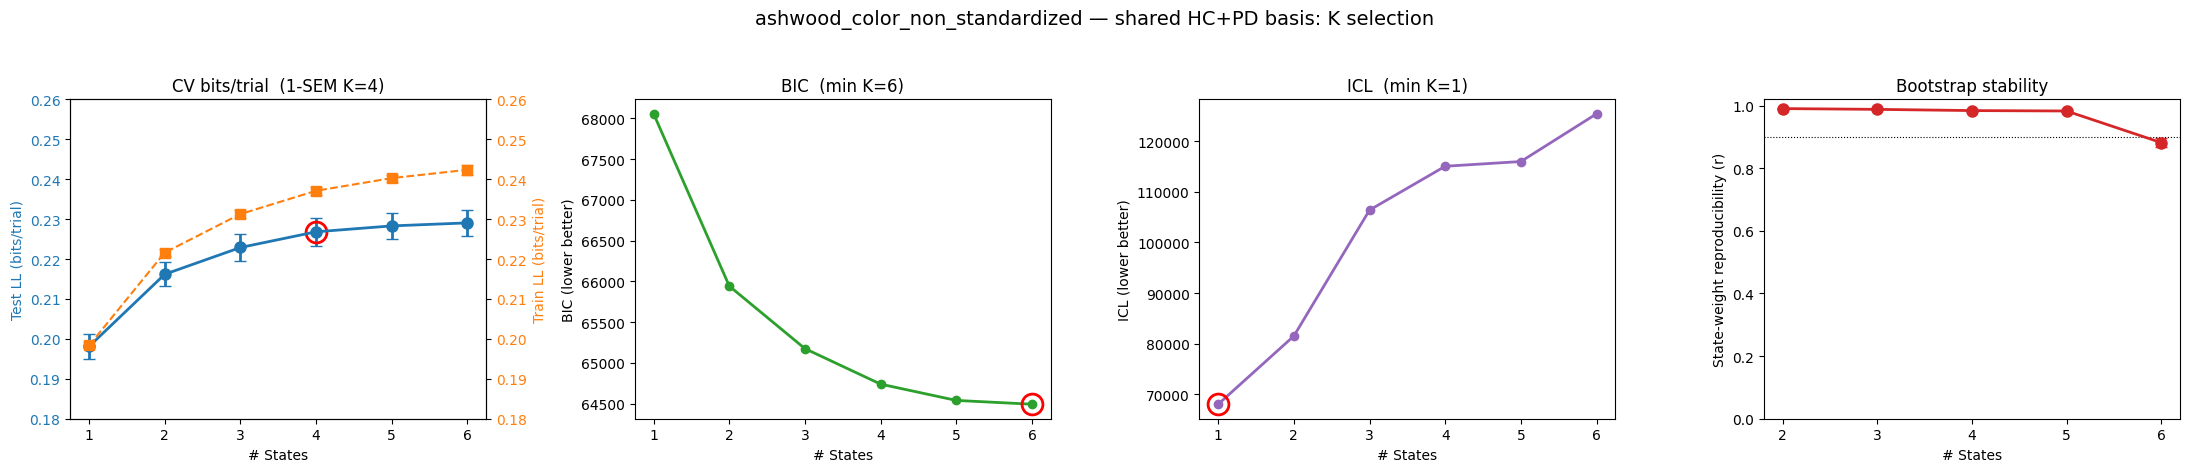

Converged K candidates -> CV(1SEM)=4  BIC=6  ICL=1
Choose K where criteria agree, then: finetune_shared_basis.py --best-k <K>


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

# (1) CV bits/trial: test (left axis) + train (right axis)
ax = axes[0]
ax.errorbar(st, cv_mean, yerr=cv_sem, marker="o", ms=8, lw=2, capsize=4, color="tab:blue", label="test")
idx = int(np.where(st == k_cv)[0][0])
ax.plot(k_cv, cv_mean[idx], "o", ms=15, mfc="none", mec="red", mew=2)
ax.axhline(0, color="k", ls=":", lw=0.8)
ax.set(xlabel="# States", title=f"CV bits/trial  (1-SEM K={k_cv})")
ax.set_ylabel("Test LL (bits/trial)", color="tab:blue")
ax.set_xticks(st.astype(int))
ax.tick_params(axis="y", labelcolor="tab:blue")
ax.set_ylim(0.18, 0.26)  # zoom in to see differences between models; CV can be slightly negative due to estimation noise
ax2 = ax.twinx()
ax2.errorbar(st, tr_mean, yerr=tr_sem, marker="s", ms=7, lw=1.5, ls="--", capsize=4, color="tab:orange", label="train")
ax2.set_ylabel("Train LL (bits/trial)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0.18, 0.26)

# (2) BIC
ax = axes[1]
ax.plot(ib.index, ib["bic"], "o-", lw=2, color="tab:green")
ax.plot(k_bic, ib.loc[k_bic, "bic"], "o", ms=15, mfc="none", mec="red", mew=2)
ax.set(xlabel="# States", ylabel="BIC (lower better)", title=f"BIC  (min K={k_bic})")
ax.set_xticks(ib.index)

# (3) ICL
ax = axes[2]
ax.plot(ib.index, ib["icl"], "o-", lw=2, color="tab:purple")
ax.plot(k_icl, ib.loc[k_icl, "icl"], "o", ms=15, mfc="none", mec="red", mew=2)
ax.set(xlabel="# States", ylabel="ICL (lower better)", title=f"ICL  (min K={k_icl})")
ax.set_xticks(ib.index)

# (4) Bootstrap stability
ax = axes[3]
ax.errorbar(stab.index, stab["mean_stability"], yerr=stab["sem_stability"], marker="o", ms=8, lw=2, capsize=4, color="tab:red")
ax.axhline(0.9, color="k", ls=":", lw=0.8)
ax.set(xlabel="# States", ylabel="State-weight reproducibility (r)", title="Bootstrap stability", ylim=(0, 1.02))
ax.set_xticks(stab.index)

fig.suptitle(f"{CONFIG} — shared HC+PD basis: K selection", fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

print(f"Converged K candidates -> CV(1SEM)={k_cv}  BIC={k_bic}  ICL={k_icl}")
print("Choose K where criteria agree, then: finetune_shared_basis.py --best-k <K>")